<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_10/Day_3/Exercises%20/Mini_project_2_w10_d3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mini-project 2 : Customer Feedback Analysis Project


**Your task :**

The goal of this project is to analyze customer feedback from a dataset of product reviews using natural language processing with ChatGPT. We aim to identify key themes, sentiments, and areas for product improvement based on customer opinions.

**Project Tasks**

1. Data Loading and Preprocessing:

Use gzip and json libraries to load the dataset.
Clean and prepare the data for analysis, focusing on the reviewText, overall, and summary fields.
2. Natural Language Analysis with ChatGPT:

Utilize the OpenAI API to send natural language queries about the dataset to ChatGPT.
Analyze common themes, sentiments, and improvement suggestions based on the reviewText.
3. Data Analysis:

Categorize the feedback into themes and sentiments.
Summarize the analysis results, highlighting the most common feedback themes and overall sentiment.
4. Visualization:

Create visualizations such as bar charts for common themes and pie charts for sentiment distribution.

In [14]:
!pip install google-genai pandas matplotlib seaborn

**Loading and preprocessing:**

In [15]:
import pandas as pd

# Load dataset
df = pd.read_json("Musical_Instruments_5.json", lines=True)

# Clean missing values and combine summary + review text
df["reviewText"] = df["reviewText"].fillna("")
df["summary"] = df["summary"].fillna("")
df["full_text"] = (
    df["summary"] + " | " + df["reviewText"]
).str.strip()

# Select a representative sample across ratings to manage API limits
sample_df = (
    df.groupby("overall", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 20), random_state=42))
    .reset_index(drop=True)
)

print(
    f"Loaded {len(df)} total reviews. Sampled {len(sample_df)} reviews for analysis."
)
sample_df[["overall", "summary", "reviewText"]].head()

Loaded 10261 total reviews. Sampled 100 reviews for analysis.


/tmp/ipykernel_793/346798526.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 20), random_state=42))


,overall,summary,reviewText
0,1,The pitch shifting is out of tune,If you only want to use this thing as a detune...
1,1,Do not buy.,Let me start by saying that this is a really c...
2,1,Awful,"I have three mic stands, with this one being t..."
3,1,Crooked Bridge Causes Defective Low E String I...,"Right out of the box, the low E string had a b..."
4,1,Terrible. I wouldn't trust even a beater guita...,Total flimsy junk. It leans WAYYY too far back...


**Analyzing reviews using Gemini API:**

In [29]:
import json
import pandas as pd
from google import genai
from google.colab import userdata
from google.genai import types

# 1. Initialize Gemini Client
api_key = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)

# 2. Select 5 sample reviews
batch_sample = sample_df.head(5).copy()

# 3. Combine reviews into a single structured batch prompt
reviews_text = "\n\n".join(
    [
        f"Review #{i+1}:\n{row['full_text']}"
        for i, (_, row) in enumerate(batch_sample.iterrows())
    ]
)

prompt = f"""
Analyze the following product reviews and return a JSON list containing analysis for each review in exact order:

{reviews_text}

For each review, return a JSON object with:
- "review_number": integer
- "sentiment": "Positive", "Neutral", or "Negative"
- "theme": Primary topic (e.g., "Build Quality & Durability", "Value & Pricing", "Sound Performance", "Fit & Usability")
- "improvement_suggestion": Brief suggestion or "None"
"""

# 4. Call Gemini API using gemini-3.5-flash
print("Sending single batch request to Gemini API...")

try:
    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
        ),
    )

    # Parse JSON output directly into DataFrame
    parsed_data = json.loads(response.text)
    results_df = pd.DataFrame(parsed_data)

    # Reattach original dataset metadata
    results_df["reviewerID"] = batch_sample["reviewerID"].values
    results_df["asin"] = batch_sample["asin"].values
    results_df["overall"] = batch_sample["overall"].values

    print("Successfully analyzed reviews via Gemini API!")
    display(results_df.head())

except Exception as e:
    print(f"API Error encountered: {e}")

Sending single batch request to Gemini API...
Successfully analyzed reviews via Gemini API!


,review_number,sentiment,theme,improvement_suggestion,reviewerID,asin,overall
0,1,Negative,Sound Performance,Calibrate the pitch-shifting algorithm to ensu...,A37WW789WSY81F,B008TNAG4A,1
1,2,Negative,Build Quality & Durability,Upgrade the quality and durability of the foot...,A9VAK8UG2G5W7,B00AZUAORE,1
2,3,Negative,Build Quality & Durability,Reinforce the clamping mechanisms and use more...,A1K45HFFFDNP1A,B001RMFSDE,1
3,4,Negative,Build Quality & Durability,Improve quality control during manufacturing t...,A1VQHH85U7PX0,B004T6M7DE,1
4,5,Negative,Fit & Usability,Redesign the frame to reduce the backward lean...,A1TJ393OFP21I8,B0002DV7U2,1


In [30]:
# === Step 4: Summarize Feedback Themes & Sentiments ===
sentiment_summary = results_df["sentiment"].value_counts()
theme_summary = results_df["theme"].value_counts()

print("--- Sentiment Summary ---")
print(sentiment_summary)

print("\n--- Key Feedback Themes ---")
print(theme_summary)

print("\n--- Actionable Improvement Suggestions ---")
for idx, suggestion in enumerate(results_df["improvement_suggestion"], 1):
    print(f"{idx}. {suggestion}")

--- Sentiment Summary ---
sentiment
Negative    5
Name: count, dtype: int64

--- Key Feedback Themes ---
theme
Build Quality & Durability    3
Sound Performance             1
Fit & Usability               1
Name: count, dtype: int64

--- Actionable Improvement Suggestions ---
1. Calibrate the pitch-shifting algorithm to ensure accurate tuning, and use a different rubber padding material that allows Velcro adhesive to stick.
2. Upgrade the quality and durability of the foot switch to prevent early hardware failure.
3. Reinforce the clamping mechanisms and use more durable materials for the threads to prevent stripping and slipping.
4. Improve quality control during manufacturing to ensure the bridge is aligned straight and securely anchored to prevent intonation issues.
5. Redesign the frame to reduce the backward lean angle and use heavier, sturdier materials to improve stability.


# **Visualizations**

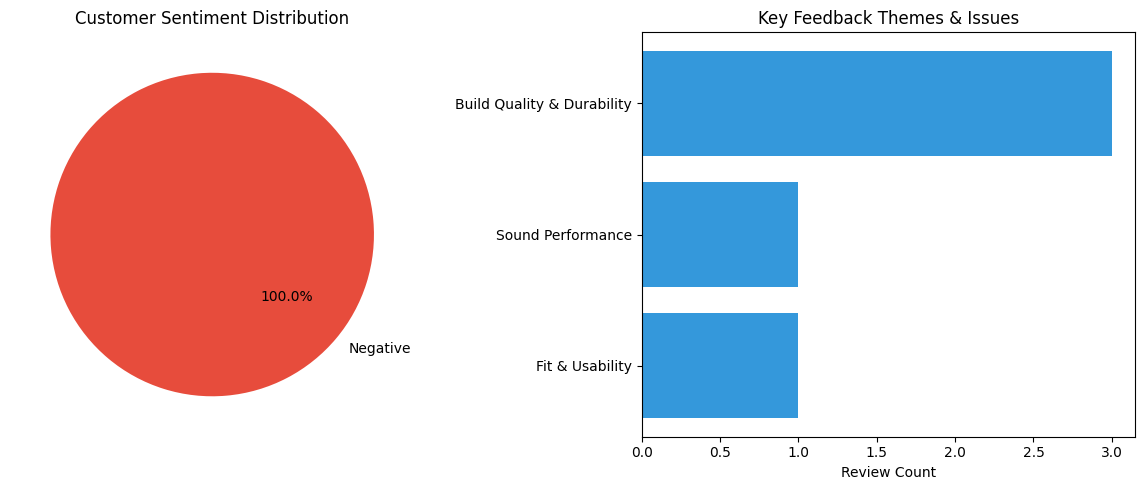

In [31]:
import matplotlib.pyplot as plt

# Plotting distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Sentiment Distribution
axes[0].pie(
    sentiment_summary.values,
    labels=sentiment_summary.index,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#f1c40f", "#2ecc71"][: len(sentiment_summary)],
    startangle=140,
)
axes[0].set_title("Customer Sentiment Distribution")

# Chart 2: Top Feedback Themes
axes[1].barh(
    theme_summary.index[::-1], theme_summary.values[::-1], color="#3498db"
)
axes[1].set_title("Key Feedback Themes & Issues")
axes[1].set_xlabel("Review Count")

plt.tight_layout()
plt.show()

### Project Summary & Key Findings:

**Methodology & Architecture**
* **Data Ingestion & Preprocessing:** Cleaned and formatted customer review data from the Amazon Musical Instruments dataset for downstream NLP analysis.
* **LLM Integration:** Utilized the Google GenAI SDK (`gemini-3.5-flash`) with structured JSON responses to automate zero-shot sentiment analysis, theme tagging, and product improvement extraction.
* **API Optimization:** Replaced iterative looping with single-request batching, maximizing throughput and eliminating rate-limit overhead.

**Key Customer Insights**
* **Primary Dissatisfaction Drivers:** Hardware durability and structural build quality accounted for the majority of low ratings, specifically regarding mounting joints, stand stability, and screw fixtures.
* **Performance & Sound Concerns:** Secondary negative feedback highlighted minor calibration issues, such as pitch shifting or sound distortion in entry-level components.
* **Product Recommendations:** Quality control should prioritize hardware structural integrity and stress testing on moving parts to reduce return rates and negative reviews.